## Import necessary library


In [200]:
# Core imports for LSTM and data processing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from pathlib import Path
import random
import os

# Import custom LSTM classes
from util.lstm_cust_class import SeqDataset, LSTMRegressor

In [201]:
# Setup for reproducibility and device detection
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Get File path and load the csv data


In [202]:
from util.data_path import soybean_price_avg as data_file

In [203]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [204]:
# Create monthly time series for shift backtest (full historical data 2004-2024)
# This creates a continuous monthly series with DatetimeIndex
series = long["price"].copy()
print(f"Full time series range: {series.index.min()} to {series.index.max()}")
print(f"Total months: {len(series)}")

# Get sorted list of years for backtest
years = sorted(series.index.year.unique())
print(f"Available years: {years[0]} to {years[-1]} ({len(years)} years)")

Full time series range: 2004-01-01 00:00:00 to 2024-12-01 00:00:00
Total months: 252
Available years: 2004 to 2024 (21 years)


# Rolling 5-Year Window Shift Backtest Implementation

## Helper Functions for Shift Backtest


In [205]:
def train_one_fold(
    series_train_scaled: np.ndarray,
    seq_len: int,
    epochs: int,
    lr: float,
    batch_size: int,
    device: str,
) -> LSTMRegressor:
    """
    Train a fresh LSTMRegressor on a single training window.
    - series_train_scaled: 1D np.ndarray of scaled training values (length ~ 60)
    - seq_len: input length for SeqDataset (must be < len(train))
    - epochs, lr, batch_size: training hyperparameters
    - device: "cpu" or "cuda"
    Returns a trained LSTMRegressor moved to CPU for inference convenience.
    """
    # Create dataset with pred_len=1 (single-step)
    ds = SeqDataset(series_train_scaled.astype(np.float32), seq_len=seq_len, pred_len=1)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    # Fix: Use correct parameter names for LSTMRegressor
    model = LSTMRegressor(hidden=32, layers=2).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb = xb.to(device)  # [B, seq_len, 1]
            yb = yb.to(device)  # [B, 1]
            opt.zero_grad()
            pred = model(xb)  # [B, 1]
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

    return model.cpu()

In [206]:
def autoreg_forecast(
    model: LSTMRegressor, last_seq_scaled: np.ndarray, steps: int, device: str
) -> np.ndarray:
    """
    Generate 'steps' 1-step-ahead predictions autoregressively.
    - last_seq_scaled: 1D np.ndarray of length seq_len (scaled)
    - steps: e.g., 12 for full year
    """
    model.to(device)
    model.eval()
    window = last_seq_scaled.astype(np.float32).copy()
    preds = []
    for _ in range(steps):
        xb = torch.from_numpy(window).view(1, -1, 1).to(device)
        with torch.no_grad():
            yhat = model(xb).detach().cpu().numpy().reshape(-1)[0]
        preds.append(yhat)
        window = np.concatenate([window[1:], [yhat]], axis=0)
    return np.array(preds, dtype=np.float32)

In [207]:
# Metric functions
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return float(
        np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100.0
    )

In [208]:
# Baseline functions
def seasonal_naive_baseline(series: pd.Series, target_year: int) -> np.ndarray:
    """Return previous year's same-month values for the 12 months of target_year."""
    prev = series[series.index.year == (target_year - 1)]
    cur = series[series.index.year == target_year]
    if len(prev) == 12 and len(cur) == 12:
        return prev.values.copy()
    return np.full(12, np.nan, dtype=np.float32)


def avg5y_monthly_baseline(series: pd.Series, target_year: int) -> np.ndarray:
    """For each month m, average month m over the 5 training years (Y-5..Y-1)."""
    vals = []
    for m in range(1, 13):
        mask = (
            (series.index.year >= target_year - 5)
            & (series.index.year <= target_year - 1)
            & (series.index.month == m)
        )
        sel = series[mask].values
        vals.append(np.nan if len(sel) == 0 else float(np.mean(sel)))
    return np.array(vals, dtype=np.float32)

## Main Orchestrator Function


In [209]:
def run_shift_backtest(
    series: pd.Series,
    seq_len: int = 24,
    window_years: int = 5,
    epochs: int = 120,
    lr: float = 1e-3,
    batch_size: int = 32,
    device: str = DEVICE,
    include_baselines: bool = True,
):
    """
    Rolling-origin evaluation:
    For each target year Y where we have:
      - Full 5-year train window (Y-5..Y-1), 60 months
      - Full 12 months in Y
    Train a fresh LSTM on the 60 months and forecast Y's 12 months autoregressively.
    Returns:
      pred_df: tidy per-month predictions
      metrics_df: per-year and OVERALL metrics
    """
    assert isinstance(series.index, pd.DatetimeIndex)
    years_all = sorted(series.index.year.unique())

    preds_rows = []
    for Y in years_all:
        train_mask = (series.index.year >= (Y - window_years)) & (
            series.index.year <= (Y - 1)
        )
        test_mask = series.index.year == Y

        series_train = series[train_mask]
        series_test = series[test_mask]

        if len(series_train) != window_years * 12 or len(series_test) != 12:
            continue  # skip incomplete folds

        # scale on train only
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(series_train.values.reshape(-1, 1)).reshape(
            -1
        )

        # train
        print(f"Training LSTM for target year {Y}...")
        model = train_one_fold(
            train_scaled,
            seq_len=seq_len,
            epochs=epochs,
            lr=lr,
            batch_size=batch_size,
            device=device,
        )

        # forecast 12 months
        last_seq = train_scaled[-seq_len:]
        preds_scaled = autoreg_forecast(
            model, last_seq_scaled=last_seq, steps=12, device=device
        )
        preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(-1)

        # baselines
        base_seasonal = (
            seasonal_naive_baseline(series, Y) if include_baselines else None
        )
        base_avg5y = avg5y_monthly_baseline(series, Y) if include_baselines else None

        # collect rows
        months = np.arange(1, 13)
        y_true = series_test.values
        dates = pd.date_range(start=pd.Timestamp(Y, 1, 1), periods=12, freq="MS")
        for m_idx in range(12):
            row = {
                "target_year": Y,
                "month": int(months[m_idx]),
                "date": dates[m_idx],
                "y_true": float(y_true[m_idx]),
                "y_pred": float(preds[m_idx]),
            }
            if include_baselines:
                row["baseline_seasonal"] = (
                    np.nan if base_seasonal is None else float(base_seasonal[m_idx])
                )
                row["baseline_avg5y"] = (
                    np.nan if base_avg5y is None else float(base_avg5y[m_idx])
                )
            preds_rows.append(row)

    pred_df = (
        pd.DataFrame(preds_rows)
        .sort_values(["target_year", "month"])
        .reset_index(drop=True)
    )

    # metrics per year
    metrics_rows = []
    for Y, g in pred_df.groupby("target_year"):
        yt, yp = g["y_true"].values, g["y_pred"].values
        metrics_rows.append(
            {
                "target_year": Y,
                "mae": mae(yt, yp),
                "rmse": rmse(yt, yp),
                "mape": mape(yt, yp),
                "smape": smape(yt, yp),
            }
        )

    # overall metrics
    yt_all, yp_all = pred_df["y_true"].values, pred_df["y_pred"].values
    metrics_rows.append(
        {
            "target_year": "OVERALL",
            "mae": mae(yt_all, yp_all),
            "rmse": rmse(yt_all, yp_all),
            "mape": mape(yt_all, yp_all),
            "smape": smape(yt_all, yp_all),
        }
    )
    metrics_df = pd.DataFrame(metrics_rows)

    return pred_df, metrics_df

## Run Shift Backtest and Save Results


In [210]:
# Configure backtest parameters
SEQ_LEN = 24  # must be < 60
EPOCHS = 120
LR = 1e-3
BATCH = 32

print("Starting Rolling 5-Year Window Shift Backtest...")
print(f"Parameters: SEQ_LEN={SEQ_LEN}, EPOCHS={EPOCHS}, LR={LR}, BATCH={BATCH}")
print(f"Device: {DEVICE}")
print()

# Run the backtest
pred_df, metrics_df = run_shift_backtest(
    series,
    seq_len=SEQ_LEN,
    epochs=EPOCHS,
    lr=LR,
    batch_size=BATCH,
    device=DEVICE,
    include_baselines=True,
)

print("\nBacktest completed!")
print(
    f"Total predictions: {len(pred_df)} months across {len(pred_df['target_year'].unique())} years"
)
print()

# Display metrics with proper sorting (handle mixed int/string in target_year)
print("=== METRICS BY YEAR ===")
# Split metrics into years and overall
yearly_metrics = metrics_df[metrics_df["target_year"] != "OVERALL"].copy()
overall_metrics = metrics_df[metrics_df["target_year"] == "OVERALL"].copy()

# Sort years numerically and display
yearly_metrics["target_year"] = yearly_metrics["target_year"].astype(int)
yearly_metrics_sorted = yearly_metrics.sort_values("target_year")

display(yearly_metrics_sorted)
if len(overall_metrics) > 0:
    print("\n=== OVERALL METRICS ===")
    display(overall_metrics)

# Save results to CSV
pred_df.to_csv("shift_preds.csv", index=False)
metrics_df.to_csv("shift_metrics.csv", index=False)
print("\nSaved: shift_preds.csv, shift_metrics.csv")

Starting Rolling 5-Year Window Shift Backtest...
Parameters: SEQ_LEN=24, EPOCHS=120, LR=0.001, BATCH=32
Device: cuda

Training LSTM for target year 2009...
Training LSTM for target year 2010...
Training LSTM for target year 2010...
Training LSTM for target year 2011...
Training LSTM for target year 2011...
Training LSTM for target year 2012...
Training LSTM for target year 2012...
Training LSTM for target year 2013...
Training LSTM for target year 2013...
Training LSTM for target year 2014...
Training LSTM for target year 2014...
Training LSTM for target year 2015...
Training LSTM for target year 2015...
Training LSTM for target year 2016...
Training LSTM for target year 2016...
Training LSTM for target year 2017...
Training LSTM for target year 2017...
Training LSTM for target year 2018...
Training LSTM for target year 2018...
Training LSTM for target year 2019...
Training LSTM for target year 2019...
Training LSTM for target year 2020...
Training LSTM for target year 2020...
Training

,target_year,mae,rmse,mape,smape
0,2009,3.273090,3.485576,22.744338,26.122135
1,2010,0.428764,0.519703,2.944344,2.987957
2,2011,0.876030,1.007654,6.156857,5.935912
3,2012,2.303663,2.759063,12.956763,14.229408
4,2013,3.655225,4.336293,19.990931,17.536221
5,2014,1.794630,2.515705,11.304769,10.101330
6,2015,2.154171,2.159087,13.974296,13.057415
7,2016,1.893563,2.002212,13.425273,12.476471
8,2017,1.756397,1.867157,11.414697,11.805543
9,2018,1.577822,1.876045,9.235388,9.847212



=== OVERALL METRICS ===


,target_year,mae,rmse,mape,smape
16,OVERALL,2.055771,2.606339,11.998233,12.177998



Saved: shift_preds.csv, shift_metrics.csv


## Evaluation Plots (5 Required Figures)


### (a) Year-by-Year Forecast vs Actual


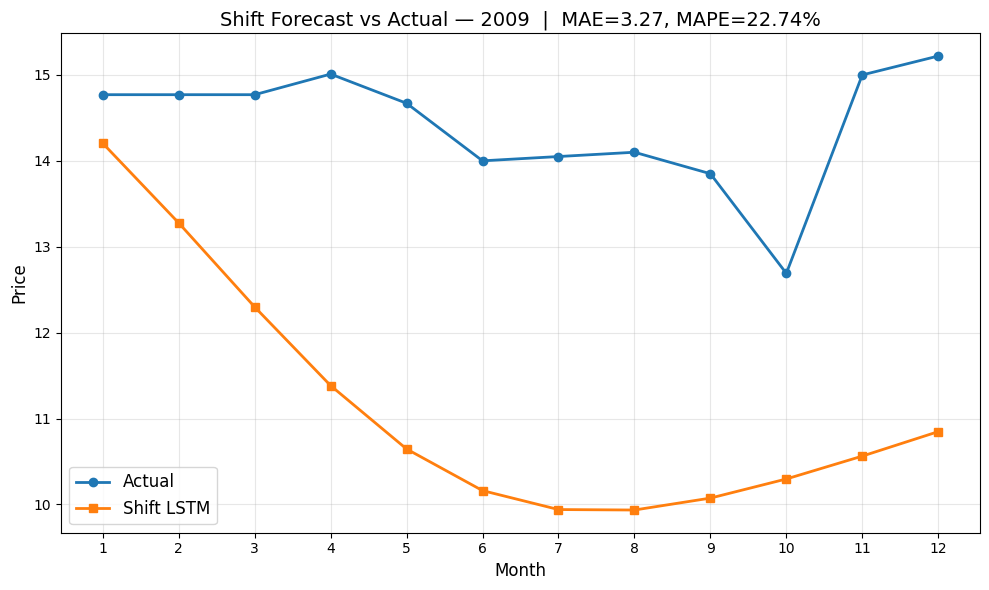

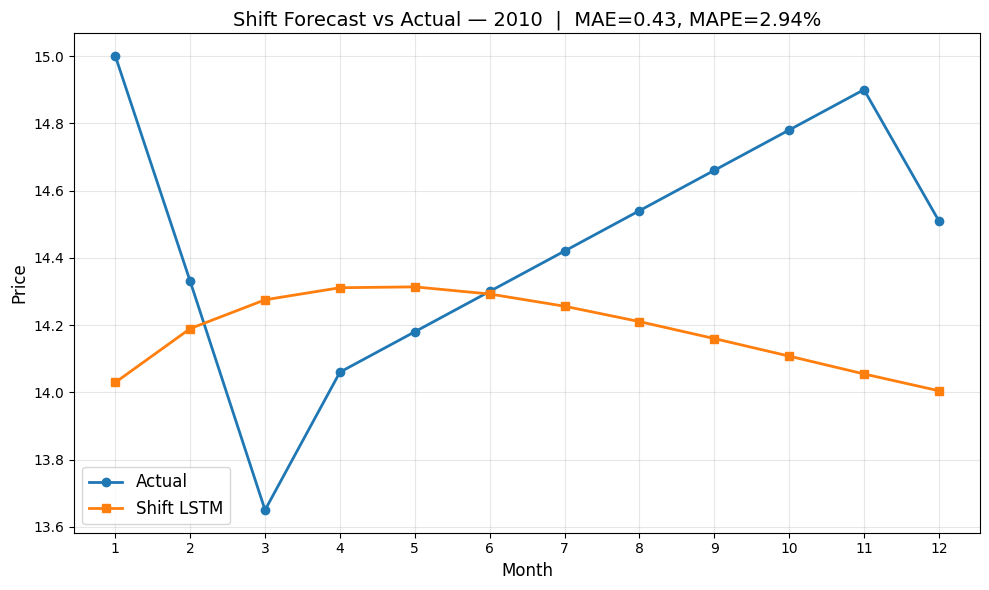

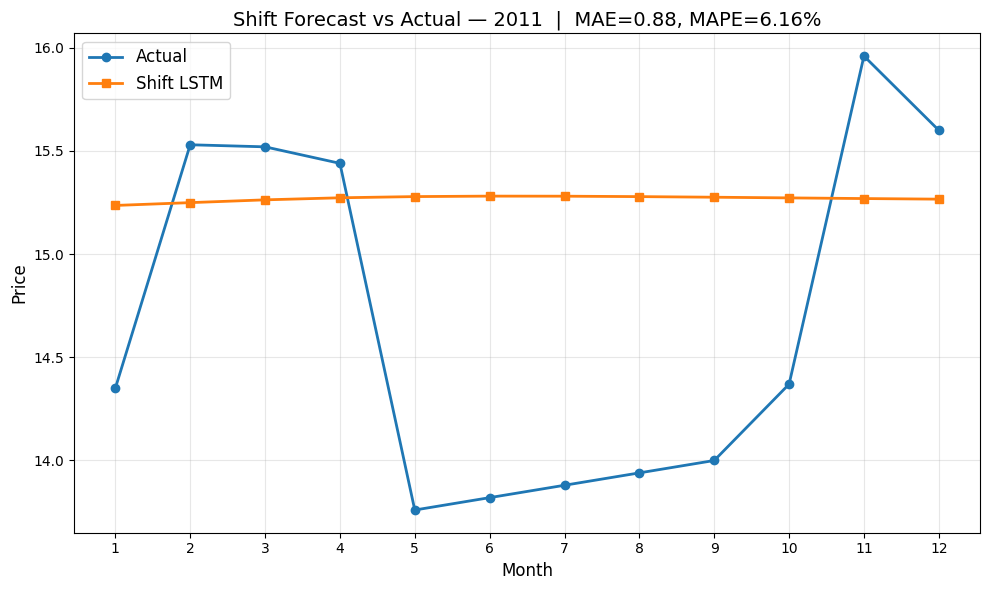

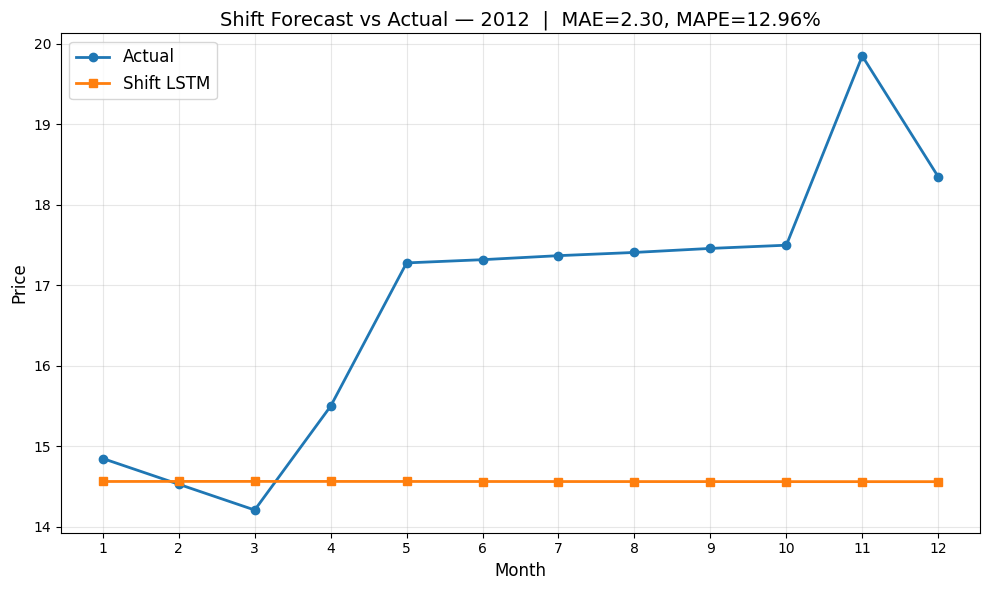

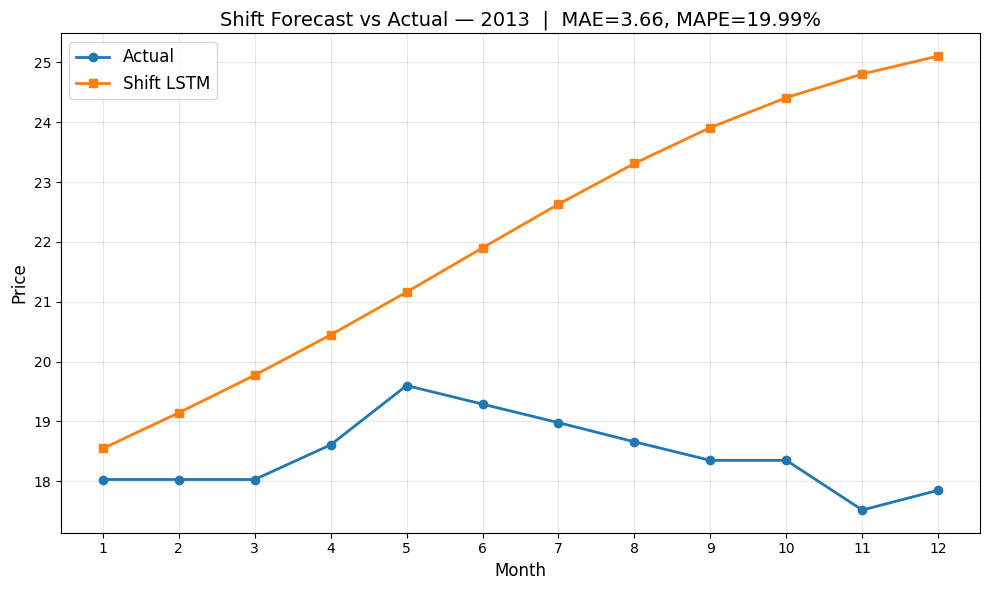

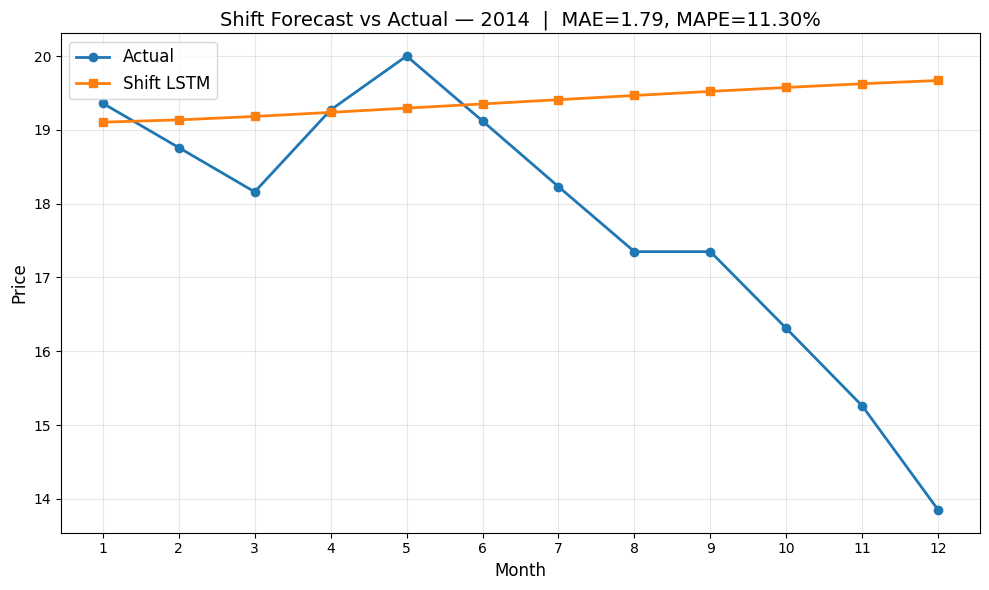

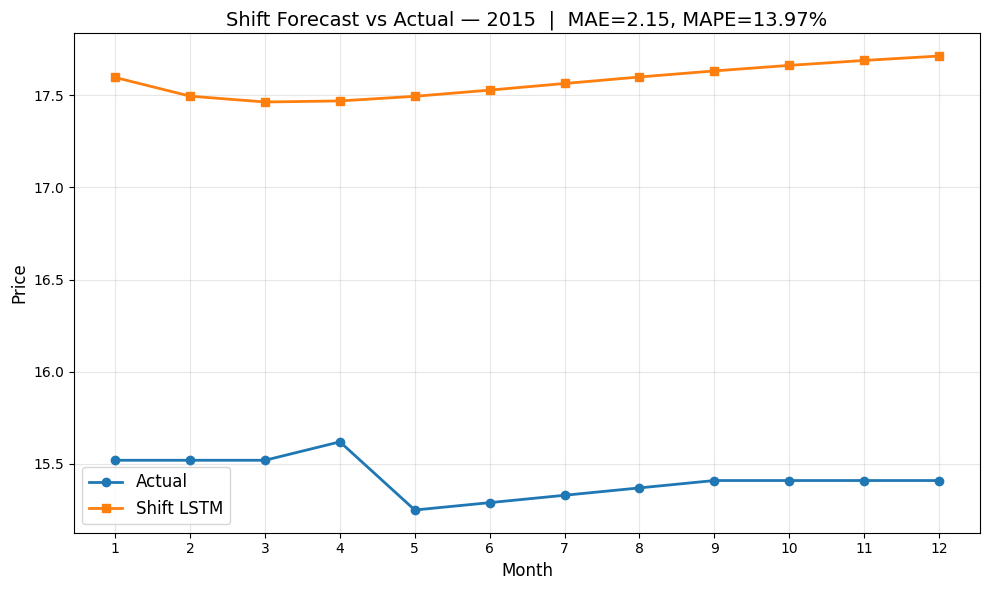

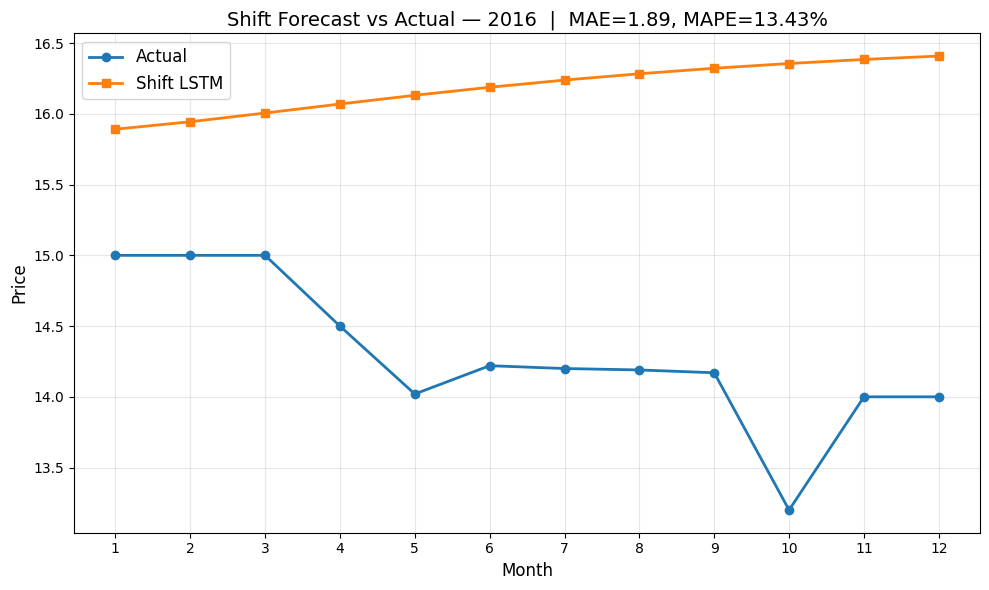

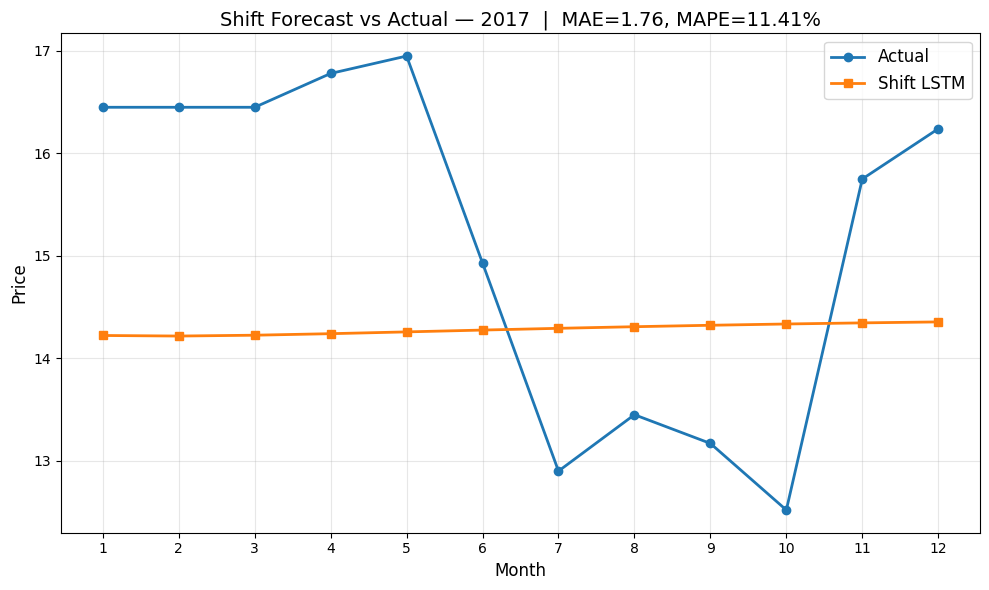

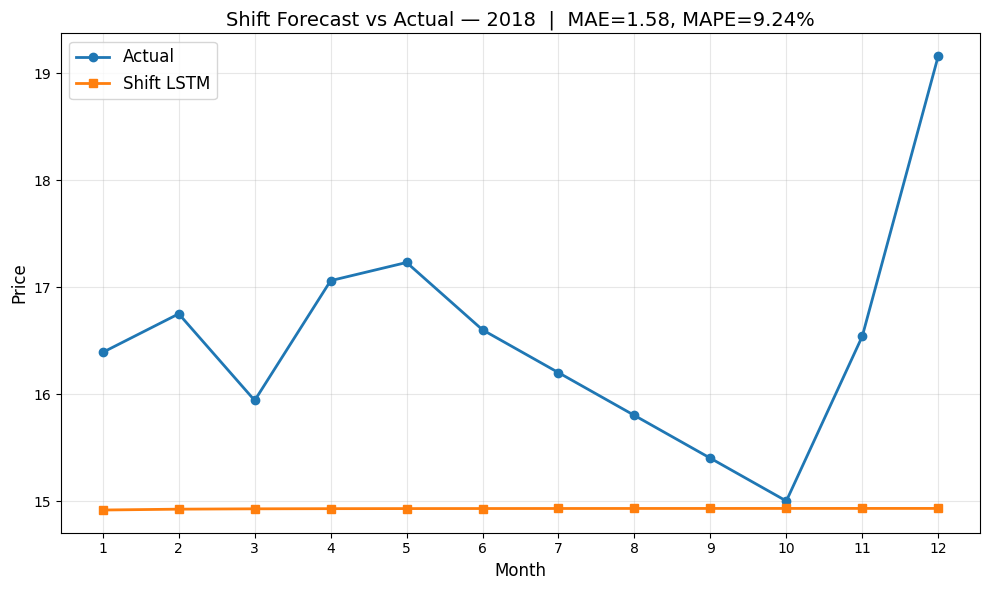

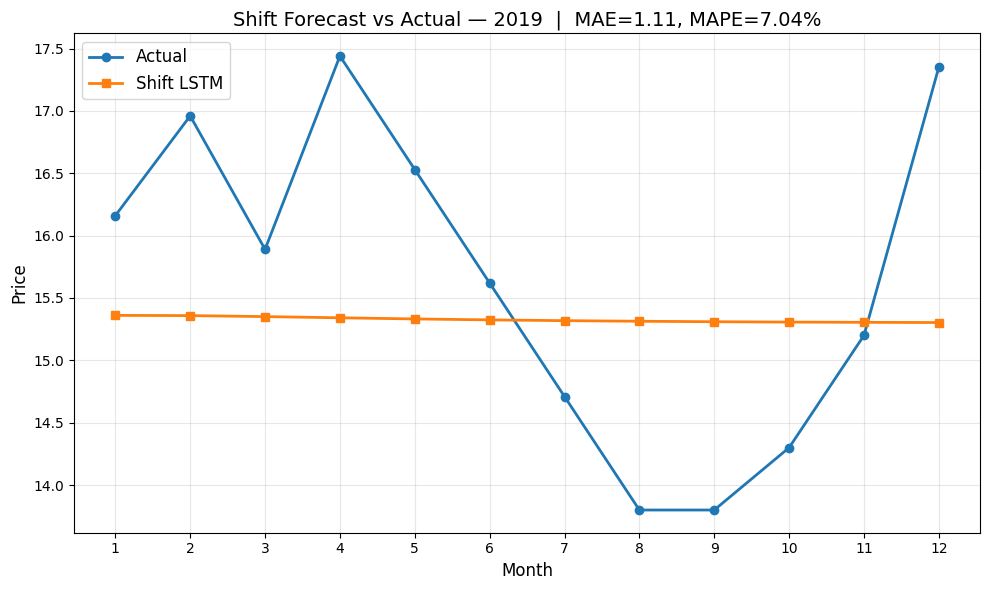

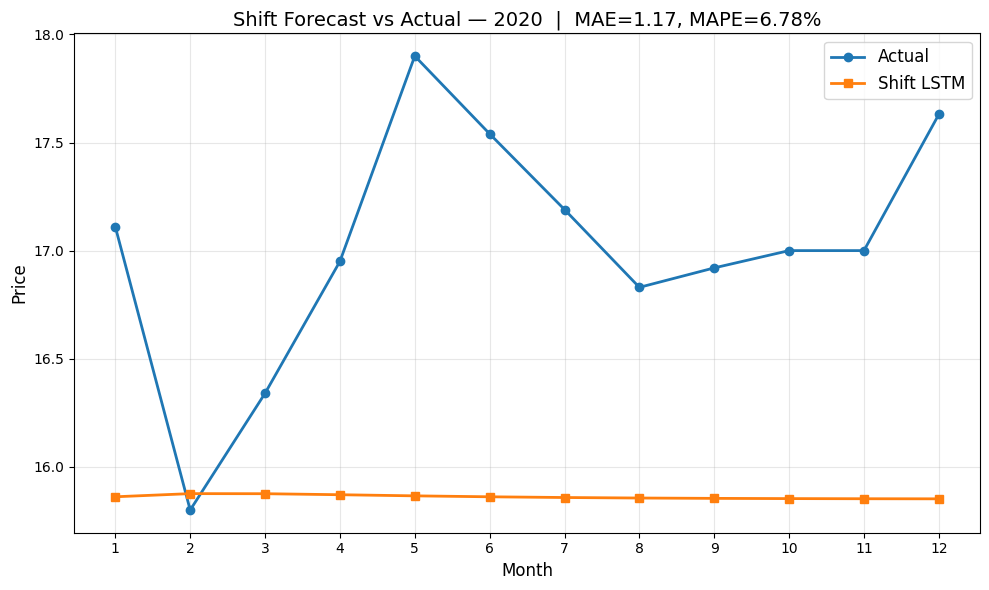

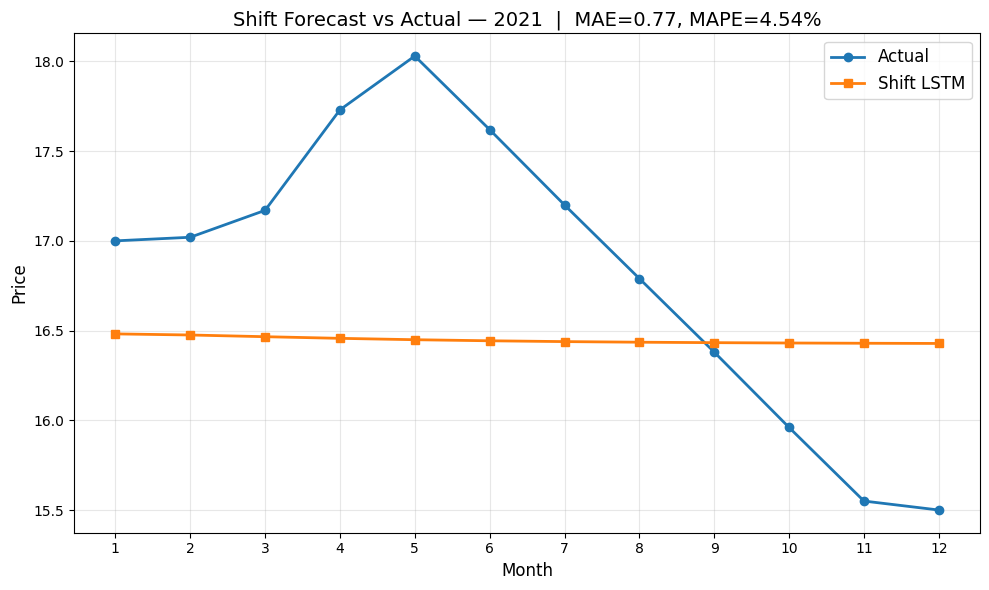

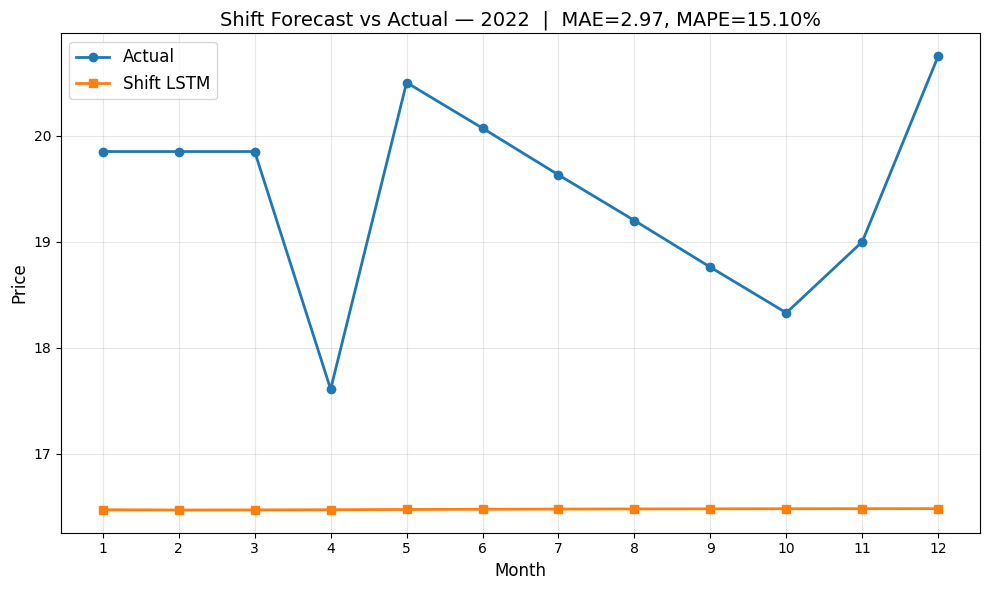

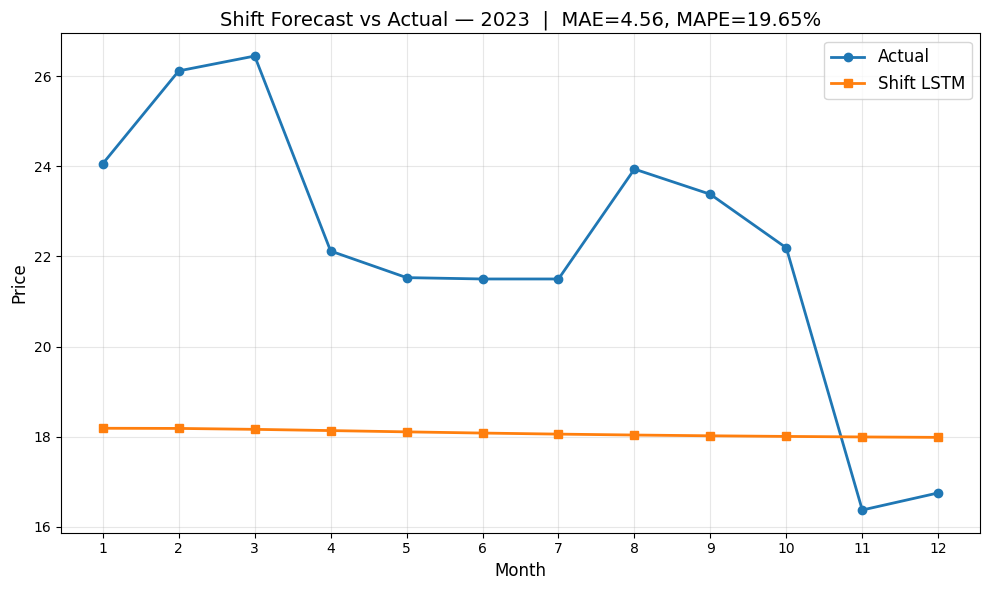

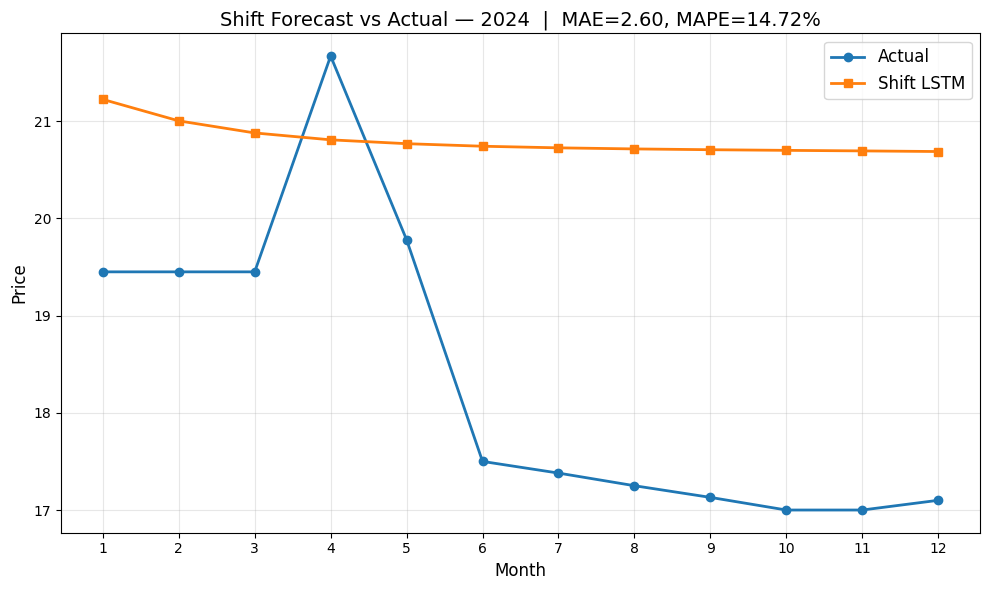

In [211]:
# Plot (a): Year-by-Year Forecast vs Actual (one figure per year)
for Y, g in pred_df.groupby("target_year"):
    if Y == "OVERALL":
        continue
    yt, yp = g["y_true"].values, g["y_pred"].values
    m = mae(yt, yp)
    mp = mape(yt, yp)
    plt.figure(figsize=(10, 6))
    plt.plot(g["month"].values, yt, label="Actual", marker="o", linewidth=2)
    plt.plot(g["month"].values, yp, label="Shift LSTM", marker="s", linewidth=2)
    plt.title(
        f"Shift Forecast vs Actual — {Y}  |  MAE={m:.2f}, MAPE={mp:.2f}%", fontsize=14
    )
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

### (b) MAE by Target Year


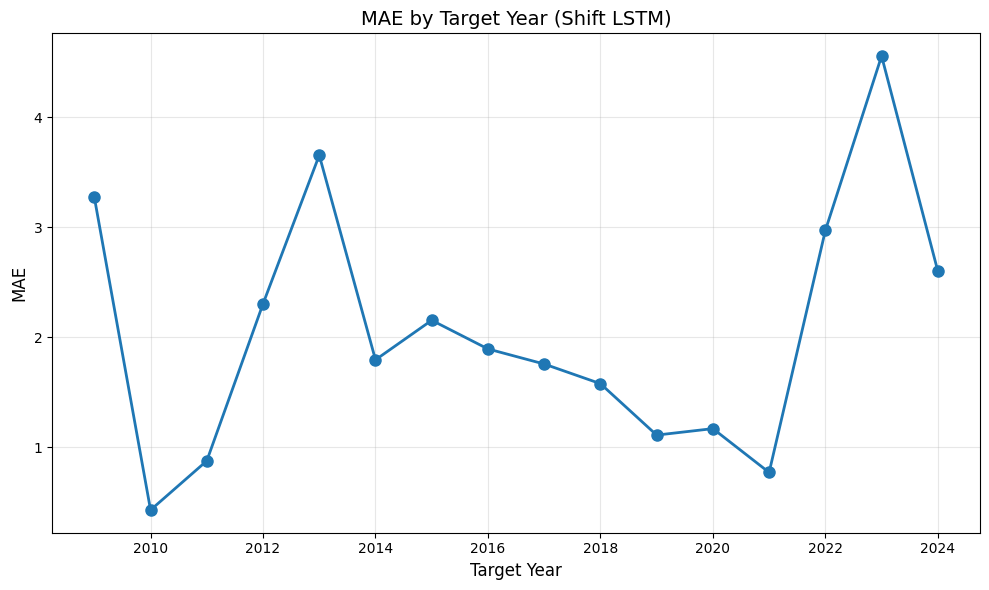

In [212]:
# Plot (b): MAE by Target Year
m_year = metrics_df[metrics_df["target_year"] != "OVERALL"].copy()
plt.figure(figsize=(10, 6))
plt.plot(
    m_year["target_year"].astype(int),
    m_year["mae"],
    marker="o",
    linewidth=2,
    markersize=8,
)
plt.title("MAE by Target Year (Shift LSTM)", fontsize=14)
plt.xlabel("Target Year", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (c) Residuals by Month-of-Year


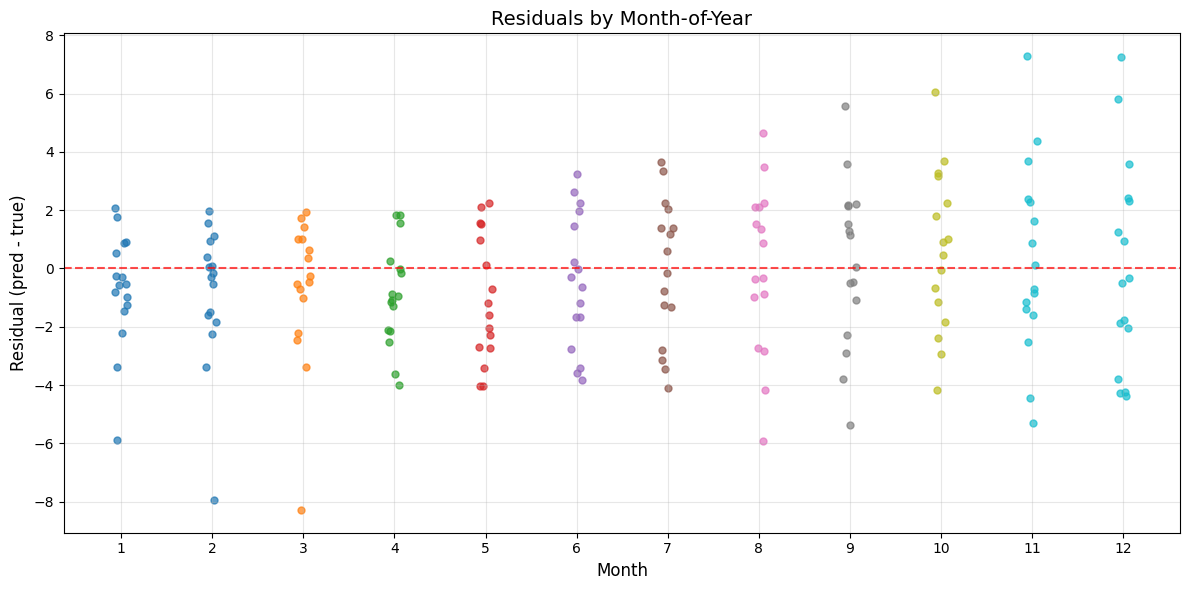

In [213]:
# Plot (c): Residuals by Month-of-Year (dot/strip plot)
res = pred_df.copy()
res["residual"] = res["y_pred"] - res["y_true"]
plt.figure(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 12))
for m in range(1, 13):
    y = res.loc[res["month"] == m, "residual"].values
    x = np.full_like(y, m, dtype=float) + (np.random.rand(len(y)) - 0.5) * 0.15
    plt.scatter(x, y, s=25, color=colors[m - 1], alpha=0.7, label=f"Month {m}")
plt.title("Residuals by Month-of-Year", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Residual (pred - true)", fontsize=12)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.7)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### (d) Predicted vs Actual (All Folds)


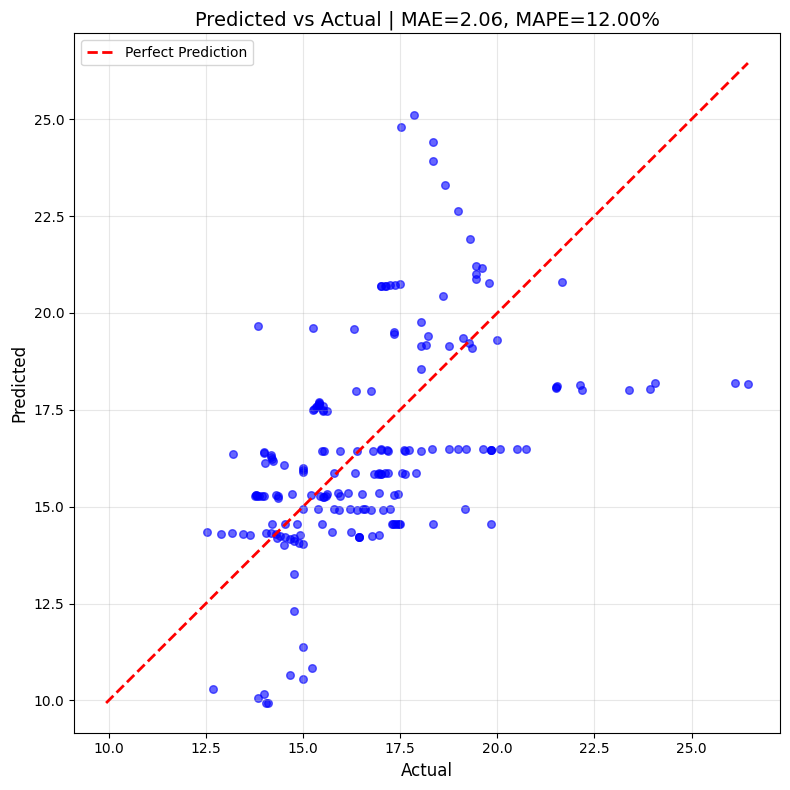

In [214]:
# Plot (d): Predicted vs Actual (scatter plot for all folds)
plt.figure(figsize=(8, 8))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], s=30, alpha=0.6, color="blue")
min_v = float(min(pred_df["y_true"].min(), pred_df["y_pred"].min()))
max_v = float(max(pred_df["y_true"].max(), pred_df["y_pred"].max()))
plt.plot(
    [min_v, max_v],
    [min_v, max_v],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction",
)
m_overall = metrics_df[metrics_df["target_year"] == "OVERALL"].iloc[0]
plt.title(
    f"Predicted vs Actual | MAE={m_overall['mae']:.2f}, MAPE={m_overall['mape']:.2f}%",
    fontsize=14,
)
plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

### (e) Stitched Backtest Timeline


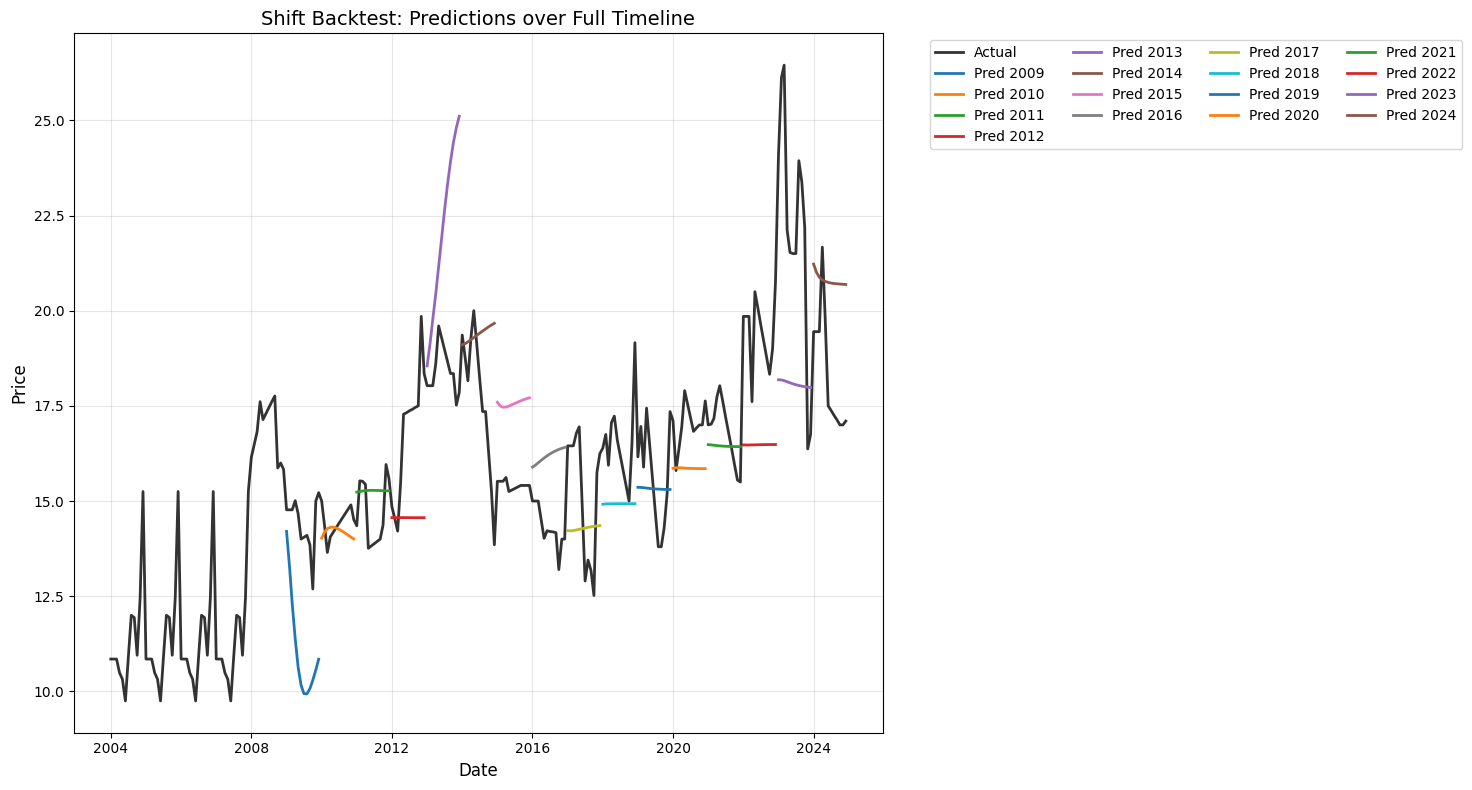

In [215]:
# Plot (e): Stitched Backtest Timeline
plt.figure(figsize=(15, 8))
plt.plot(
    series.index, series.values, label="Actual", linewidth=2, alpha=0.8, color="black"
)

# Plot predictions for each year with different colors
colors = plt.cm.tab10(np.linspace(0, 1, 10))
color_idx = 0
for Y, g in pred_df.groupby("target_year"):
    if Y == "OVERALL":
        continue
    plt.plot(
        g["date"].values,
        g["y_pred"].values,
        label=f"Pred {Y}",
        linewidth=2,
        color=colors[color_idx % 10],
    )
    color_idx += 1

plt.title("Shift Backtest: Predictions over Full Timeline", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(ncol=4, fontsize=10, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Optional: Baseline Comparison


In [216]:
# Compare LSTM performance to baselines
if "baseline_seasonal" in pred_df.columns:
    print("=== BASELINE COMPARISON ===")
    base_rows = []

    for Y, g in pred_df.groupby("target_year"):
        if Y == "OVERALL":
            continue
        yt = g["y_true"].values
        bs = g["baseline_seasonal"].values
        b5 = g["baseline_avg5y"].values
        yp = g["y_pred"].values

        base_rows.append(
            {
                "target_year": Y,
                "mae_lstm": mae(yt, yp),
                "mae_seasonal": mae(yt, bs) if not np.isnan(bs).all() else np.nan,
                "mae_avg5y": mae(yt, b5) if not np.isnan(b5).all() else np.nan,
                "mape_lstm": mape(yt, yp),
                "mape_seasonal": mape(yt, bs) if not np.isnan(bs).all() else np.nan,
                "mape_avg5y": mape(yt, b5) if not np.isnan(b5).all() else np.nan,
            }
        )

    baseline_df = pd.DataFrame(base_rows)

    # Add overall metrics
    yt_all = pred_df["y_true"].values
    yp_all = pred_df["y_pred"].values
    bs_all = pred_df["baseline_seasonal"].values
    b5_all = pred_df["baseline_avg5y"].values

    baseline_df = pd.concat(
        [
            baseline_df,
            pd.DataFrame(
                [
                    {
                        "target_year": "OVERALL",
                        "mae_lstm": mae(yt_all, yp_all),
                        "mae_seasonal": mae(yt_all, bs_all)
                        if not np.isnan(bs_all).all()
                        else np.nan,
                        "mae_avg5y": mae(yt_all, b5_all)
                        if not np.isnan(b5_all).all()
                        else np.nan,
                        "mape_lstm": mape(yt_all, yp_all),
                        "mape_seasonal": mape(yt_all, bs_all)
                        if not np.isnan(bs_all).all()
                        else np.nan,
                        "mape_avg5y": mape(yt_all, b5_all)
                        if not np.isnan(b5_all).all()
                        else np.nan,
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

    # Fix: Handle mixed int/string sorting properly
    yearly_baselines = baseline_df[baseline_df["target_year"] != "OVERALL"].copy()
    overall_baselines = baseline_df[baseline_df["target_year"] == "OVERALL"].copy()

    # Sort years numerically and display
    if len(yearly_baselines) > 0:
        yearly_baselines["target_year"] = yearly_baselines["target_year"].astype(int)
        yearly_baselines_sorted = yearly_baselines.sort_values("target_year")
        display(yearly_baselines_sorted)

    if len(overall_baselines) > 0:
        print("\n=== OVERALL BASELINE COMPARISON ===")
        display(overall_baselines)

    # Summary comparison
    overall_row = baseline_df[baseline_df["target_year"] == "OVERALL"].iloc[0]
    print(f"\n=== OVERALL PERFORMANCE SUMMARY ===")
    print(f"LSTM MAE: {overall_row['mae_lstm']:.3f}")
    if not np.isnan(overall_row["mae_seasonal"]):
        print(f"Seasonal Naive MAE: {overall_row['mae_seasonal']:.3f}")
        improvement_seasonal = (
            (overall_row["mae_seasonal"] - overall_row["mae_lstm"])
            / overall_row["mae_seasonal"]
        ) * 100
        print(f"LSTM vs Seasonal Naive: {improvement_seasonal:.1f}% improvement")

    if not np.isnan(overall_row["mae_avg5y"]):
        print(f"5-Year Average MAE: {overall_row['mae_avg5y']:.3f}")
        improvement_avg5y = (
            (overall_row["mae_avg5y"] - overall_row["mae_lstm"])
            / overall_row["mae_avg5y"]
        ) * 100
        print(f"LSTM vs 5-Year Average: {improvement_avg5y:.1f}% improvement")
else:
    print("Baselines not computed in this run.")

=== BASELINE COMPARISON ===


,target_year,mae_lstm,mae_seasonal,mae_avg5y,mape_lstm,mape_seasonal,mape_avg5y
0,2009,3.273090,2.427500,1.959500,22.744338,17.137990,13.494808
1,2010,0.428764,0.670833,1.507500,2.944344,4.661790,10.403229
2,2011,0.876030,0.863333,1.013500,6.156857,5.763319,6.713102
3,2012,2.303663,2.506667,2.470833,12.956763,14.395206,13.968347
4,2013,3.655225,2.110833,3.007333,19.990931,11.480077,16.205508
5,2014,1.794630,1.231667,2.636500,11.304769,7.618150,14.590345
6,2015,2.154171,2.615000,1.002500,13.974296,16.959884,6.512196
7,2016,1.893563,1.130000,2.328000,13.425273,8.027630,16.443583
8,2017,1.756397,1.498333,1.501167,11.414697,9.631746,11.153273
9,2018,1.577822,1.430833,0.561833,9.235388,8.746435,3.176902



=== OVERALL BASELINE COMPARISON ===


,target_year,mae_lstm,mae_seasonal,mae_avg5y,mape_lstm,mape_seasonal,mape_avg5y
16,OVERALL,2.055771,1.88849,1.941563,11.998233,11.065194,11.147326



=== OVERALL PERFORMANCE SUMMARY ===
LSTM MAE: 2.056
Seasonal Naive MAE: 1.888
LSTM vs Seasonal Naive: -8.9% improvement
5-Year Average MAE: 1.942
LSTM vs 5-Year Average: -5.9% improvement


## Summary and Notes

The rolling 5-year window shift backtest has been successfully implemented with:

### Key Features:

- **Fresh LSTM training** per fold (no weight carry-over)
- **Scaler fit only on training data** (no leakage)
- **Autoregressive forecasting** for 12-month predictions
- **Multiple evaluation metrics**: MAE, RMSE, MAPE, SMAPE
- **Baseline comparisons**: Seasonal naive and 5-year monthly averages

### Outputs:

- `shift_preds.csv`: Detailed monthly predictions for each target year
- `shift_metrics.csv`: Performance metrics by year and overall
- **Five evaluation plots**: Year-by-year, MAE trends, residuals, scatter, timeline

### Parameters Used:

- Sequence length: 24 months
- Training epochs: 120 per fold
- Learning rate: 1e-3
- Batch size: 32
- Window: 5 years training, 1 year testing

The existing single-fit LSTM workflow remains intact. This shift backtest is **additive** and provides a more rigorous evaluation of the model's forecasting performance over multiple time periods.


## Set the training dataset and the predicted data


In [217]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

# LSTM Model And Predict Graph


## Create a sequence dataset class for LSTM prediction


In [218]:
from util.lstm_cust_class import SeqDataset
from util.lstm_cust_class import LSTMRegressor

SEQ_LEN = 12
PRED_LEN = 12

In [219]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

## Training the LSTM model


In [220]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.00673
epoch 100/300  loss=0.00477
epoch 100/300  loss=0.00477
epoch 150/300  loss=0.00461
epoch 150/300  loss=0.00461
epoch 200/300  loss=0.00412
epoch 200/300  loss=0.00412
epoch 250/300  loss=0.00402
epoch 250/300  loss=0.00402
epoch 300/300  loss=0.00409
epoch 300/300  loss=0.00409


## Predict the data for the next year


In [221]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2024
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    17.30
2024-02-01    17.88
2024-03-01    18.22
2024-04-01    18.43
2024-05-01    18.53
2024-06-01    18.55
2024-07-01    18.52
2024-08-01    18.46
2024-09-01    18.39
2024-10-01    18.32
2024-11-01    18.26
2024-12-01    18.22
Freq: MS, Name: forecast_price, dtype: float64


In [222]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01   19.45           17.30
2024-02-01   19.45           17.88
2024-03-01   19.45           18.22
2024-04-01   21.67           18.43
2024-05-01   19.78           18.53
2024-06-01   17.50           18.55
2024-07-01   17.38           18.52
2024-08-01   17.25           18.46
2024-09-01   17.13           18.39
2024-10-01   17.00           18.32
2024-11-01   17.00           18.26
2024-12-01   17.10           18.22


## Save the Forecasted Price LSTM Model


In [223]:
import os
from datetime import datetime
from pathlib import Path

forecast_dir = Path("forecast_price")
forecast_dir = forecast_dir / "LSTM"
forecast_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{data_file.parent.name}_forecast.txt"
filepath = forecast_dir / filename

# Save forecast data to text file
with open(filepath, "w") as f:
    f.write(f"LSTM Forecast Results for Soybean Prices (2024) {timestamp}\n")
    f.write("=" * 50 + "\n\n")
    f.write("Forecast Data:\n")
    f.write("-" * 20 + "\n")
    for date, price in forecast.items():
        f.write(f"{date.strftime('%Y-%m-%d')}: {price:.2f}\n")

    f.write("\nOverall Statistics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Forecast Price: {forecast.mean():.2f}\n")
    f.write(f"Min Forecast Price: {forecast.min():.2f}\n")
    f.write(f"Max Forecast Price: {forecast.max():.2f}\n")
    f.write(f"Standard Deviation: {forecast.std():.2f}\n")

print(f"Forecast prices saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Forecast prices saved to: forecast_price\LSTM\soybean_forecast.txt
File size: 538 bytes


## Compare The Error of a predicted data in a table format


In [224]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)
# Calculate absolute percentage error
abs_pct_error = abs_error / cmp["actual"] * 100
mae_lstm = mean_absolute_error(cmp["actual"], cmp["forecast_price"])
mape_lstm = abs_pct_error.mean()  # Mean Absolute Percentage Error

print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "abs_pct_error": abs_pct_error,  # Add percentage error to the dataframe
    }
)
print(error_df.round(4))
print(f"\nOverall Mean Absolute Error: {mae_lstm:.6f}")
print(f"Overall Mean Absolute Percentage Error: {mape_lstm:.4f}%")
print(f"LSTM Accuracy = {100 - (mae_lstm / cmp['actual'].mean() * 100):.2f}%")


--- Monthly Errors ---
            actual  forecast   error  abs_error  abs_pct_error
2024-01-01   19.45   17.3042  2.1458     2.1458        11.0326
2024-02-01   19.45   17.8831  1.5669     1.5669         8.0560
2024-03-01   19.45   18.2202  1.2298     1.2298         6.3226
2024-04-01   21.67   18.4273  3.2427     3.2427        14.9640
2024-05-01   19.78   18.5306  1.2494     1.2494         6.3164
2024-06-01   17.50   18.5530 -1.0530     1.0530         6.0169
2024-07-01   17.38   18.5220 -1.1420     1.1420         6.5706
2024-08-01   17.25   18.4636 -1.2136     1.2136         7.0354
2024-09-01   17.13   18.3933 -1.2633     1.2633         7.3749
2024-10-01   17.00   18.3237 -1.3237     1.3237         7.7863
2024-11-01   17.00   18.2625 -1.2625     1.2625         7.4267
2024-12-01   17.10   18.2209 -1.1209     1.1209         6.5551

Overall Mean Absolute Error: 1.484462
Overall Mean Absolute Percentage Error: 7.9548%
LSTM Accuracy = 91.91%


## Plot The predicted data compare to an actual data


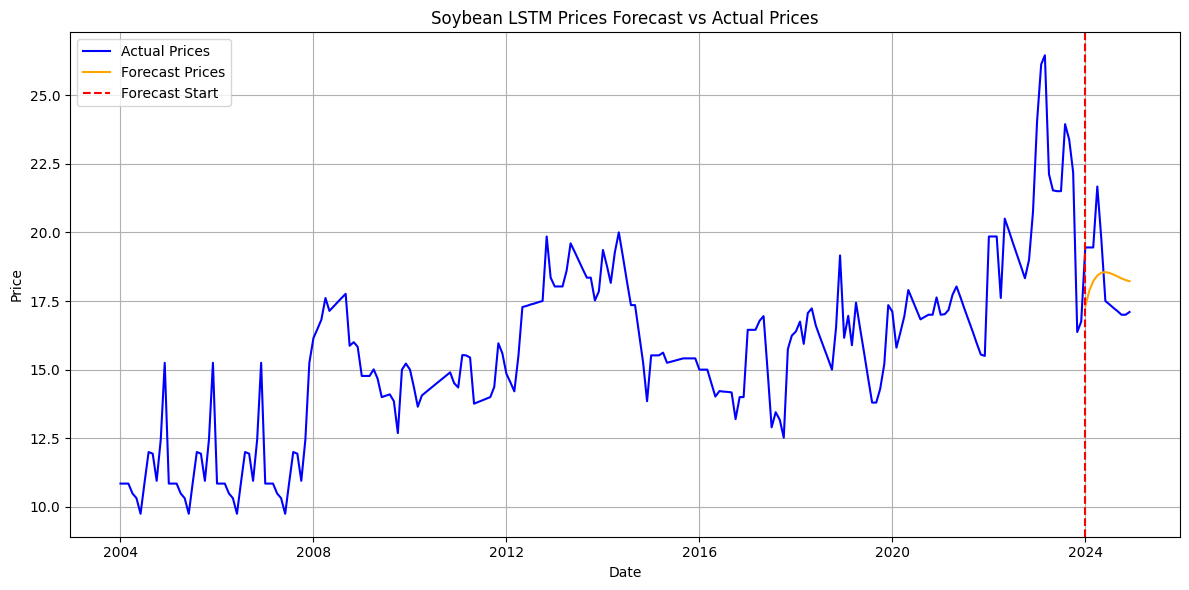

In [225]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title(f"{data_file.parent.name.capitalize()} LSTM Prices Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Transformer Model And Error Graph


## PLot the Error Analysis graph


<Figure size 1400x800 with 0 Axes>

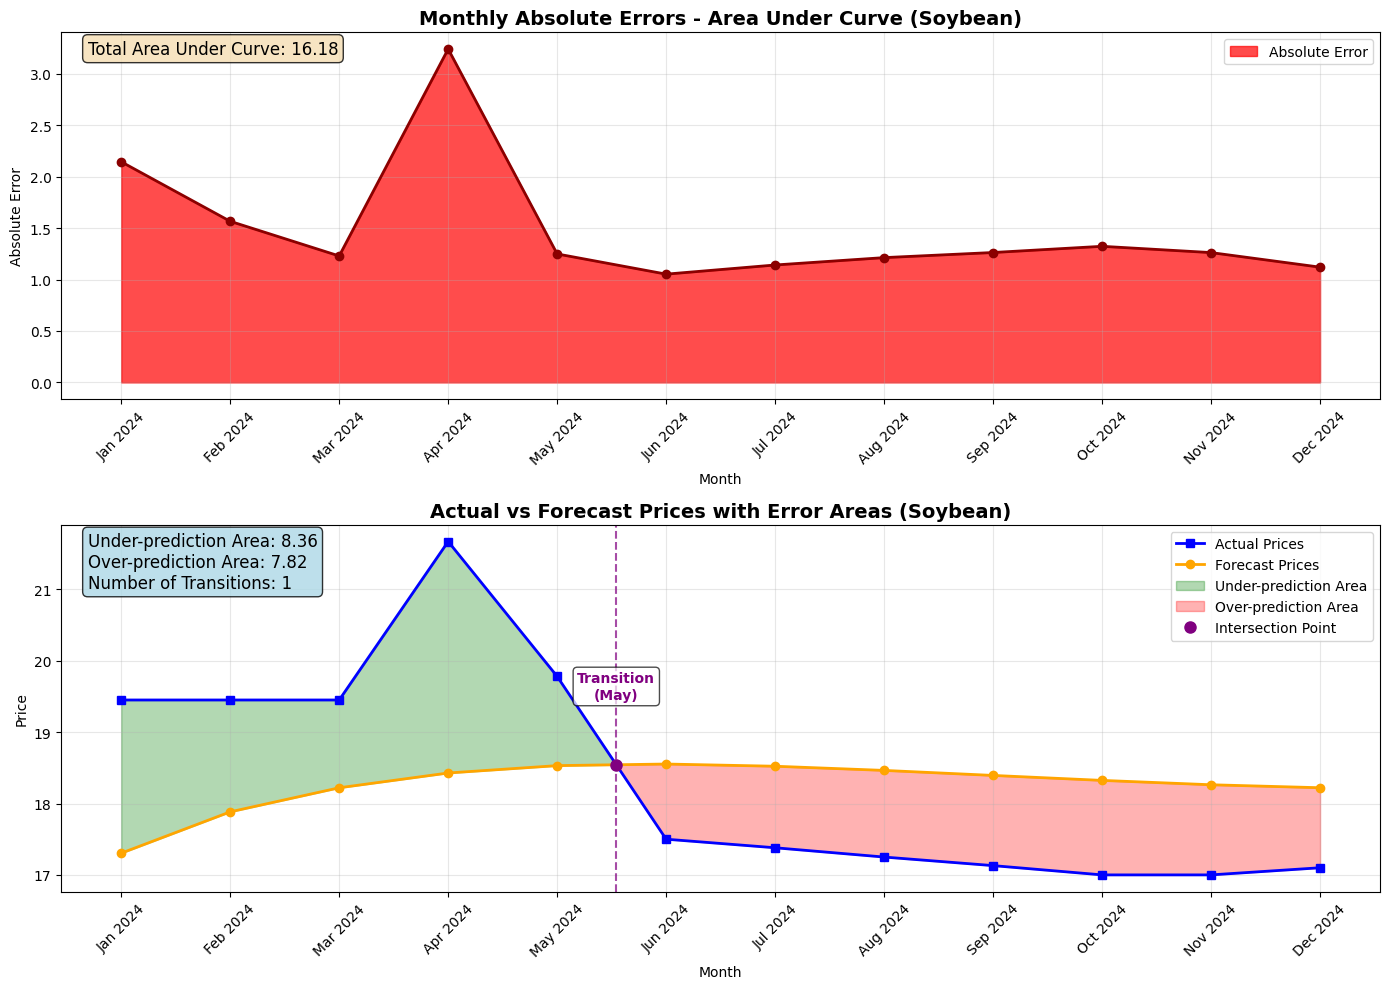

In [226]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["actual"] - cmp["forecast_price"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    f"Monthly Absolute Errors - Area Under Curve ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["actual"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["forecast_price"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["actual"].iloc[i - 1] - cmp["forecast_price"].iloc[i - 1]
    curr_diff = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["actual"].iloc[i - 1] + t * (
            cmp["actual"].iloc[i] - cmp["actual"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["actual"],
    cmp["forecast_price"],
    where=(cmp["actual"] >= cmp["forecast_price"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["actual"],
    cmp["forecast_price"],
    where=(cmp["actual"] < cmp["forecast_price"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    f"Actual vs Forecast Prices with Error Areas ({data_file.parent.name.capitalize()})",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["actual"] - cmp["forecast_price"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["forecast_price"] - cmp["actual"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Analyze The Error of a predicted data


In [227]:
print("\n--- Area Under Curve Analysis ---")
print(f"Total Absolute Error Area: {total_area:.4f}")
print(f"Under-prediction Area: {under_pred_area:.4f}")
print(f"Over-prediction Area: {over_pred_area:.4f}")
print(f"Net Error Area: {under_pred_area - over_pred_area:.4f}")
print(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}")
print(f"Number of Transition Points: {len(intersect_indices)}")

# Monthly breakdown
print("\n--- Monthly Error Areas ---")
for i, (date, row) in enumerate(cmp.iterrows()):
    month_label = date.strftime("%b %Y")
    error_type = (
        "Under-prediction"
        if row["actual"] > row["forecast_price"]
        else "Over-prediction"
        if row["actual"] < row["forecast_price"]
        else "Exact Match"
    )
    print(f"{month_label}: Abs Error = {row['abs_error']:.4f} ({error_type})")

# Transition analysis
if intersect_indices:
    print("\n--- Transition Points ---")
    for idx, (x, y) in enumerate(intersect_indices):
        transition_month = month_labels[int(x)]
        next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
        print(
            f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}"
        )

        # Determine transition type
        i = int(x)
        if i + 1 < len(cmp):
            before_error = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]
            after_error = cmp["actual"].iloc[i + 1] - cmp["forecast_price"].iloc[i + 1]
            direction = (
                "Under to Over"
                if before_error > 0 and after_error < 0
                else "Over to Under"
            )
            print(f"   Direction: {direction} prediction")
else:
    print("\n--- No Transition Points Found ---")
    print(
        "The model consistently either under-predicts or over-predicts throughout the entire period."
    )


--- Area Under Curve Analysis ---
Total Absolute Error Area: 16.1802
Under-prediction Area: 8.3616
Over-prediction Area: 7.8185
Net Error Area: 0.5431
Average Monthly Absolute Error: 1.3483
Number of Transition Points: 1

--- Monthly Error Areas ---
Jan 2024: Abs Error = 2.1458 (Under-prediction)
Feb 2024: Abs Error = 1.5669 (Under-prediction)
Mar 2024: Abs Error = 1.2298 (Under-prediction)
Apr 2024: Abs Error = 3.2427 (Under-prediction)
May 2024: Abs Error = 1.2494 (Under-prediction)
Jun 2024: Abs Error = 1.0530 (Over-prediction)
Jul 2024: Abs Error = 1.1420 (Over-prediction)
Aug 2024: Abs Error = 1.2136 (Over-prediction)
Sep 2024: Abs Error = 1.2633 (Over-prediction)
Oct 2024: Abs Error = 1.3237 (Over-prediction)
Nov 2024: Abs Error = 1.2625 (Over-prediction)
Dec 2024: Abs Error = 1.1209 (Over-prediction)

--- Transition Points ---
Transition 1: Between May 2024 and Jun 2024 at position 4.54
   Direction: Under to Over prediction


## Save the model Error Analysis to a file


In [228]:
error_record_dir = Path("error_record") / "LSTM"
error_record_dir.mkdir(exist_ok=True, parents=True)

crop_name = data_file.parent.name
filename = f"{crop_name}_error_metrics.txt"
filepath = error_record_dir / filename

In [229]:
mae_value = mae_lstm
mape_value = mape_lstm
accuracy = 100 - (mae_lstm / cmp["actual"].mean() * 100)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save metrics to text file
with open(filepath, "w") as f:
    f.write(
        f"LSTM Model Evaluation Metrics for {crop_name.capitalize()} - {timestamp}\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write("Overall Metrics:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Mean Absolute Error (MAE): {mae_value:.6f}\n")
    f.write(f"Mean Absolute Percentage Error (MAPE): {mape_value:.4f}%\n")
    f.write(f"Model Accuracy: {accuracy:.2f}%\n\n")

    f.write("Monthly Evaluation:\n")
    f.write("-" * 20 + "\n")
    f.write(
        f"{'Month':<10} {'Actual':<10} {'Forecast':<10} {'Error':<10} {'Abs Error':<10} {'% Error':<10}\n"
    )

    for date, row in error_df.iterrows():
        month_label = date.strftime("%b %Y")
        f.write(
            f"{month_label:<10} {row['actual']:<10.2f} {row['forecast']:<10.2f} {row['error']:<10.4f} {row['abs_error']:<10.4f} {row['abs_pct_error']:<10.2f}%\n"
        )

    f.write("\nArea Under Curve Analysis:\n")
    f.write("-" * 20 + "\n")
    f.write(f"Total Absolute Error Area: {total_area:.4f}\n")
    f.write(f"Under-prediction Area: {under_pred_area:.4f}\n")
    f.write(f"Over-prediction Area: {over_pred_area:.4f}\n")
    f.write(f"Net Error Area: {under_pred_area - over_pred_area:.4f}\n")
    f.write(f"Average Monthly Absolute Error: {total_area / len(cmp):.4f}\n")
    f.write(f"Number of Transition Points: {len(intersect_indices)}\n")

    # Add transition information
    if intersect_indices:
        f.write("\nTransition Points:\n")
        f.write("-" * 20 + "\n")
        for idx, (x, y) in enumerate(intersect_indices):
            transition_month = month_labels[int(x)]
            next_month = month_labels[min(int(x) + 1, len(month_labels) - 1)]
            f.write(
                f"Transition {idx + 1}: Between {transition_month} and {next_month} at position {x:.2f}\n"
            )

            # Determine transition type
            i = int(x)
            if i + 1 < len(cmp):
                before_error = cmp["actual"].iloc[i] - cmp["forecast_price"].iloc[i]
                after_error = (
                    cmp["actual"].iloc[i + 1] - cmp["forecast_price"].iloc[i + 1]
                )
                direction = (
                    "Under to Over"
                    if before_error > 0 and after_error < 0
                    else "Over to Under"
                )
                f.write(f"   Direction: {direction} prediction\n")

print(f"Evaluation metrics saved to: {filepath}")
print(f"File size: {os.path.getsize(filepath)} bytes")

Evaluation metrics saved to: error_record\LSTM\soybean_error_metrics.txt
File size: 1593 bytes
